In [1]:
# Standard NVAR = NG-RC
import numpy as np
import matplotlib.pyplot as plt
import itertools
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# ============================================================
# 1. Reproducibility
# ============================================================
seed = 2025
np.random.seed(seed)

# ============================================================
# 2. Time Setup
# ============================================================
dt = np.float32(1.0)
warmup, traintime, valtime, testtime = (np.float32(100.0),
                                        np.float32(3900.0),
                                        np.float32(500.0),
                                        np.float32(500.0))
maxtime = warmup + traintime + valtime + testtime

# Convert to discrete steps
warmup_pts    = int(round(warmup / dt))
traintime_pts = int(round(traintime / dt))
valtime_pts   = int(round(valtime / dt))
testtime_pts  = int(round(testtime / dt))
warmtrain_pts = warmup_pts + traintime_pts
val_end       = warmtrain_pts + valtime_pts
maxtime_pts   = int(round(maxtime / dt))

print("==== Data Splits (time steps) ====")
print(f" Warmup : {warmup_pts}")
print(f" Train  : {traintime_pts}")
print(f" Val    : {valtime_pts}")
print(f" Test   : {testtime_pts}")
print(f" Total  : {maxtime_pts}\n")

# ============================================================
# 3. Load Clean Data
# ============================================================
data = np.load("lorenz63_noise_0.npy", allow_pickle=True).item()
X_soln = data["data"].astype(np.float32)
meta = data["meta"]
d, T_full = X_soln.shape

X_soln = X_soln[:, :maxtime_pts + 1]
t_eval = np.linspace(0, maxtime, maxtime_pts + 1).astype(np.float32)

print(f"Loaded data shape: (d={d}, T={X_soln.shape[1]})")

# ============================================================
# 4. Load Noisy Data
# ============================================================
noise_scale = 0.10
data_noisy = np.load("lorenz63_noise_10.npy", allow_pickle=True).item()
X_noisy = data_noisy["data"][:, :maxtime_pts + 1].astype(np.float32)

print("\n==== Noise Check ====")
print(" Before (first 5):", X_soln[0, :5])
print(" After  (first 5):", X_noisy[0, :5])
print(" Mean abs diff   :", np.mean(np.abs(X_noisy - X_soln)), "\n")

# ============================================================
# 5. Model Parameters
# ============================================================
k_values     = [2, 10, 30, 50]
ridge_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4]
results = []

# ============================================================
# 6. Feature Construction (FLOAT32)
# ============================================================
def build_features(data, k, start_idx, end_idx):
    d, T = data.shape
    assert start_idx >= k - 1

    length = end_idx - start_idx
    dlin = k * d
    dnonlin = (dlin * (dlin + 1)) // 2
    dtot = 1 + dlin + dnonlin

    # Linear delay block
    lin_block = np.zeros((dlin, length), dtype=np.float32)
    for i, t in enumerate(range(start_idx, end_idx)):
        lin_block[:, i] = np.hstack([
            data[:, t - delay] for delay in range(k)
        ]).astype(np.float32)

    # Full feature block
    out = np.ones((dtot, length), dtype=np.float32)
    out[1:1 + dlin, :] = lin_block

    # Quadratic block
    cnt = 0
    for r in range(dlin):
        for c in range(r, dlin):
            out[1 + dlin + cnt, :] = lin_block[r, :] * lin_block[c, :]
            cnt += 1

    return out, lin_block

# ============================================================
# 7. Grid Search
# ============================================================
window_size = 100
print("==== Grid Search Results ====")

for k, ridge_param in itertools.product(k_values, ridge_values):
    dlin = k * d
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    # --- Training ---
    start_feat = warmup_pts - 1
    end_feat = warmtrain_pts - 1
    if start_feat < (k - 1):
        raise ValueError("Not enough history for chosen k")

    out_train, _ = build_features(X_noisy, k, start_feat, end_feat)

    delta_x = (X_noisy[:, warmup_pts:warmtrain_pts] -
               X_noisy[:, warmup_pts - 1:warmtrain_pts - 1]).astype(np.float32)

    # Gram matrix
    C = (out_train @ out_train.T).astype(np.float32)
    regularizer = (ridge_param * np.eye(C.shape[0], dtype=np.float32))

    # Solve W_out
    try:
        W_out = delta_x @ out_train.T @ np.linalg.solve(
            C + regularizer,
            np.eye(C.shape[0], dtype=np.float32)
        )
    except np.linalg.LinAlgError:
        W_out = delta_x @ out_train.T @ np.linalg.pinv(
            (C + regularizer).astype(np.float32)
        )
    W_out = W_out.astype(np.float32)

    # --- Validation ---
    rmses = []

    for start in range(warmtrain_pts, val_end, window_size):
        end = min(start + window_size, val_end)
        if end - start < window_size:
            continue

        history = [X_noisy[:, start - k + i].copy().astype(np.float32)
                   for i in range(k)]

        pred = np.zeros((d, window_size), dtype=np.float32)

        for j in range(window_size):
            z = np.hstack([history[-1 - i] for i in range(k)]).astype(np.float32)

            out_test = np.ones((dtot, 1), dtype=np.float32)
            out_test[1:1 + dlin, 0] = z

            cnt = 0
            for r in range(dlin):
                for c in range(r, dlin):
                    out_test[1 + dlin + cnt, 0] = z[r] * z[c]
                    cnt += 1

            delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
            next_x = history[-1] + delta_pred
            pred[:, j] = next_x
            history.append(next_x)

        true = X_soln[:, start:end]
        rmses.append(np.sqrt(np.mean((true - pred)**2)))

    avg_rmse = np.mean(rmses) if rmses else np.inf
    results.append((k, ridge_param, avg_rmse))

    print(f" k={k:<2d} | ridge={ridge_param:>6.1e} | Avg Val RMSE={avg_rmse:.6f}")




==== Data Splits (time steps) ====
 Warmup : 100
 Train  : 3900
 Val    : 500
 Test   : 500
 Total  : 5000

Loaded data shape: (d=3, T=5001)

==== Noise Check ====
 Before (first 5): [-0.8437777  -0.5016289  -0.23222724 -0.02159939  0.14331546]
 After  (first 5): [-0.9272395  -0.49635968 -0.26114354 -0.04288653  0.20923851]
 Mean abs diff   : 0.07966966 

==== Grid Search Results ====
 k=2  | ridge=1.0e-07 | Avg Val RMSE=0.912386
 k=2  | ridge=1.0e-06 | Avg Val RMSE=0.912386
 k=2  | ridge=1.0e-05 | Avg Val RMSE=0.912386
 k=2  | ridge=1.0e-04 | Avg Val RMSE=0.912386
 k=2  | ridge=1.0e-03 | Avg Val RMSE=0.911895
 k=2  | ridge=1.0e-02 | Avg Val RMSE=0.909045
 k=2  | ridge=1.0e-01 | Avg Val RMSE=0.904525
 k=2  | ridge=1.0e+00 | Avg Val RMSE=0.901645
 k=2  | ridge=1.0e+01 | Avg Val RMSE=0.969197
 k=2  | ridge=1.0e+02 | Avg Val RMSE=1.046445
 k=2  | ridge=1.0e+03 | Avg Val RMSE=1.120095
 k=2  | ridge=1.0e+04 | Avg Val RMSE=0.976558
 k=10 | ridge=1.0e-07 | Avg Val RMSE=0.467936
 k=10 | ridge=

/tmp/ipython-input-1797459967.py:165: RuntimeWarning: overflow encountered in scalar multiply
  out_test[1 + dlin + cnt, 0] = z[r] * z[c]
/tmp/ipython-input-1797459967.py:168: RuntimeWarning: invalid value encountered in matmul
  delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
/tmp/ipython-input-1797459967.py:174: RuntimeWarning: overflow encountered in square
  rmses.append(np.sqrt(np.mean((true - pred)**2)))
/tmp/ipython-input-1797459967.py:168: RuntimeWarning: overflow encountered in matmul
  delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)


 k=30 | ridge=1.0e-07 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-06 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-05 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-04 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-03 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-02 | Avg Val RMSE=nan
 k=30 | ridge=1.0e-01 | Avg Val RMSE=nan
 k=30 | ridge=1.0e+00 | Avg Val RMSE=0.378464
 k=30 | ridge=1.0e+01 | Avg Val RMSE=0.387502
 k=30 | ridge=1.0e+02 | Avg Val RMSE=0.657608
 k=30 | ridge=1.0e+03 | Avg Val RMSE=0.717314
 k=30 | ridge=1.0e+04 | Avg Val RMSE=0.818879
 k=50 | ridge=1.0e-07 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-06 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-05 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-04 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-03 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-02 | Avg Val RMSE=nan
 k=50 | ridge=1.0e-01 | Avg Val RMSE=nan
 k=50 | ridge=1.0e+00 | Avg Val RMSE=nan
 k=50 | ridge=1.0e+01 | Avg Val RMSE=0.865184
 k=50 | ridge=1.0e+02 | Avg Val RMSE=0.202556
 k=50 | ridge=1.0e+03 | Avg Val RMSE=0.499366
 k=50 | ridge=1.0

In [2]:
# ============================================================
# 1. Select Best Model
# ============================================================
valid_results = [(k, ridge, rmse) for (k, ridge, rmse) in results if np.isfinite(rmse)]
best_k, best_ridge, best_rmse = min(valid_results, key=lambda x: x[2])

print("\n==== Best Model ====")
print(f"k = {best_k}, ridge = {best_ridge:.2e} → Avg. Validation RMSE = {best_rmse:.6f}\n")

# ============================================================
# 2. Retrain on TRAIN using Best Parameters
# ============================================================
start_feat = warmup_pts - 1
end_feat = warmtrain_pts - 1

out_train, lin_train = build_features(X_noisy, best_k, start_feat, end_feat)

delta_x = (X_noisy[:, warmup_pts:warmtrain_pts] -
           X_noisy[:, warmup_pts - 1:warmtrain_pts - 1]).astype(np.float32)

C = (out_train @ out_train.T).astype(np.float32)
W_out = delta_x @ out_train.T @ np.linalg.pinv(
    C + best_ridge * np.eye(C.shape[0], dtype=np.float32)
)
W_out = W_out.astype(np.float32)

# ============================================================
# 3. Testing (Non-overlapping Windows)
# ============================================================
test_start, test_end = val_end, maxtime_pts
window_size = 100

all_true, all_pred, all_t, all_rmse = [], [], [], []

horizons = [25, 50, 75, 100]
horizon_rmses = {h: [] for h in horizons}

dlin = best_k * d
dnonlin = (dlin * (dlin + 1)) // 2
dtot = 1 + dlin + dnonlin

for start in range(test_start, test_end, window_size):
    end = min(start + window_size, test_end)
    if end - start < window_size:
        continue

    history = [X_noisy[:, start - best_k + i].copy().astype(np.float32)
               for i in range(best_k)]

    pred = np.zeros((d, window_size), dtype=np.float32)

    for j in range(window_size):
        z = np.hstack([history[-1 - i] for i in range(best_k)]).astype(np.float32)

        out_test = np.ones((dtot, 1), dtype=np.float32)
        out_test[1:1 + dlin, 0] = z

        cnt = 0
        for r in range(dlin):
            for c in range(r, dlin):
                out_test[1 + dlin + cnt, 0] = z[r] * z[c]
                cnt += 1

        delta_pred = (W_out @ out_test).reshape(d).astype(np.float32)
        next_x = history[-1] + delta_pred
        pred[:, j] = next_x
        history.append(next_x)

    true = X_soln[:, start:end]

    # Horizon RMSEs
    for h in horizons:
        if h <= pred.shape[1]:
            rmse_h = np.sqrt(np.mean((true[:, :h] - pred[:, :h])**2, axis=1))
            horizon_rmses[h].append(rmse_h)

    rmse_full = np.sqrt(np.mean((true - pred)**2))
    all_rmse.append((start, end, rmse_full))

    all_true.append(true)
    all_pred.append(pred)
    all_t.extend(range(start, end))

all_true = np.hstack(all_true).astype(np.float32) if all_true else np.empty((d, 0), dtype=np.float32)
all_pred = np.hstack(all_pred).astype(np.float32) if all_pred else np.empty((d, 0), dtype=np.float32)

# ============================================================
# 4. Horizon-wise RMSE Summary
# ============================================================
variables = [f"x_{i+1}" for i in range(d)]

print("\n==== Horizon-wise RMSE Summary ====")
for h in horizons:
    if len(horizon_rmses[h]) == 0:
        continue
    rmse_arr = np.vstack(horizon_rmses[h]).astype(np.float32)  # (num_windows, d)
    mean_per_var = np.mean(rmse_arr, axis=0)
    overall = np.mean(mean_per_var)

    print(f"\n-- Horizon {h} steps --")
    for i, v in enumerate(variables):
        print(f"Variable {v}: RMSE = {mean_per_var[i]:.6f}")
    print(f"Overall avg. RMSE = {overall:.6f}")


==== Best Model ====
k = 50, ridge = 1.00e+02 → Avg. Validation RMSE = 0.202556


==== Horizon-wise RMSE Summary ====

-- Horizon 25 steps --
Variable x_1: RMSE = 0.196745
Variable x_2: RMSE = 0.313324
Variable x_3: RMSE = 0.341663
Overall avg. RMSE = 0.283911

-- Horizon 50 steps --
Variable x_1: RMSE = 0.245472
Variable x_2: RMSE = 0.318893
Variable x_3: RMSE = 0.376663
Overall avg. RMSE = 0.313676

-- Horizon 75 steps --
Variable x_1: RMSE = 0.299527
Variable x_2: RMSE = 0.330146
Variable x_3: RMSE = 0.414424
Overall avg. RMSE = 0.348033

-- Horizon 100 steps --
Variable x_1: RMSE = 0.368205
Variable x_2: RMSE = 0.400292
Variable x_3: RMSE = 0.505857
Overall avg. RMSE = 0.424785


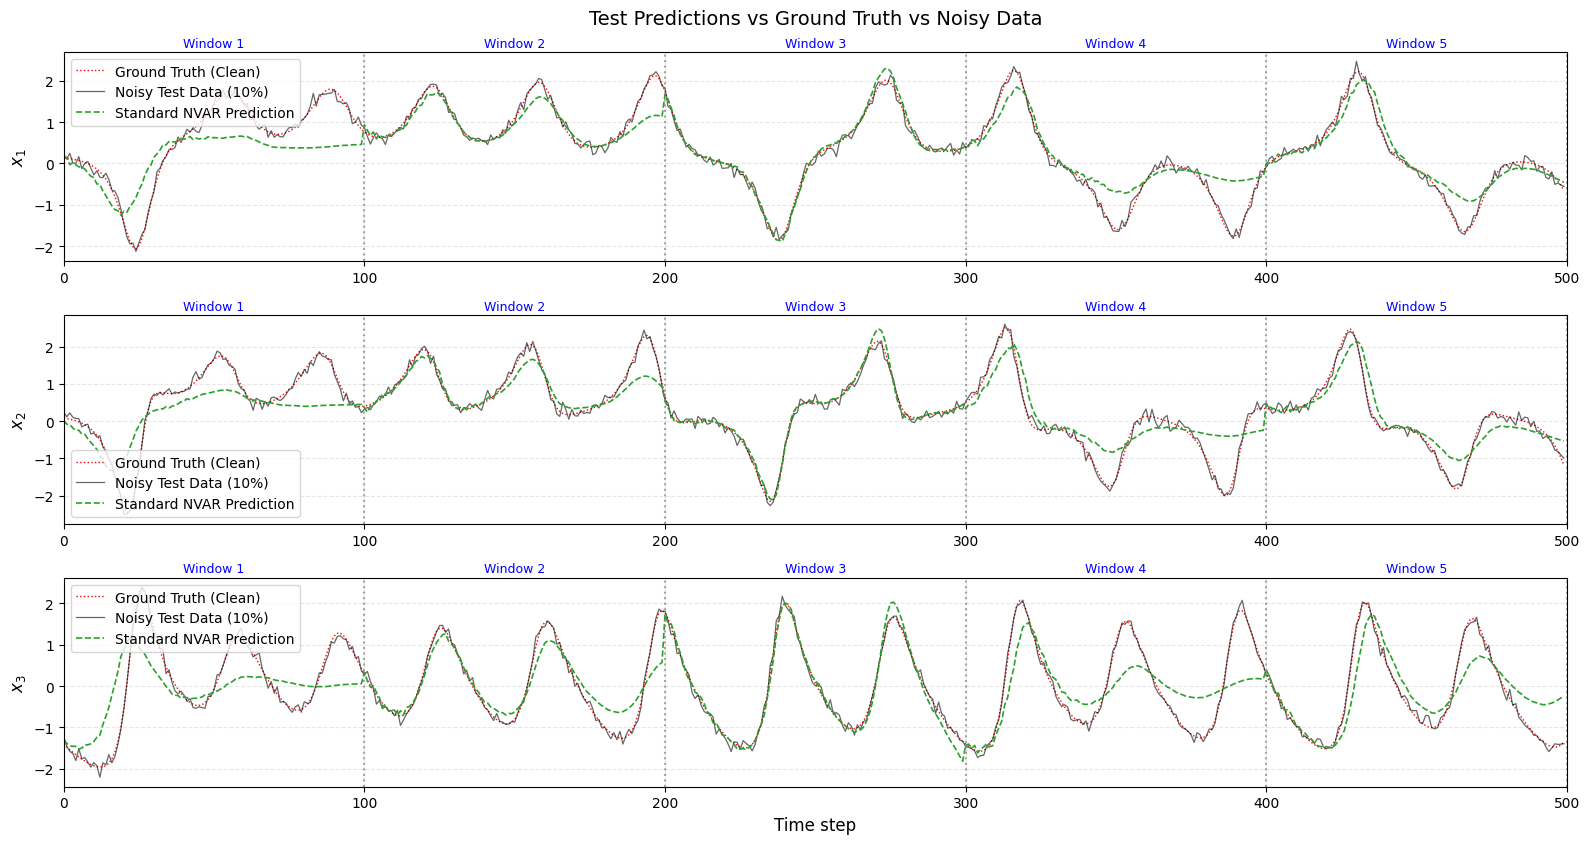

Saved plot as: Test_pred_vs_truth_allvars_k50_ridge1.0e+02_noise0.10.png


In [3]:
# ============================================================
# 5. Plot All Variables Separately  (FLOAT32-SAFE)
# ============================================================

# Variable names
variables = [f"x_{i+1}" for i in range(d)]

# Ensure arrays are float32 before plotting (matplotlib can upcast)
all_true = all_true.astype(np.float32)
all_pred = all_pred.astype(np.float32)

# Relative time vector
t_rel = np.arange(all_true.shape[1], dtype=np.float32)

plt.figure(figsize=(16, 3 * d))

for i, var in enumerate(variables):
    plt.subplot(d, 1, i + 1)

    # -----------------------------
    # 1. Ground Truth
    # -----------------------------
    plt.plot(
        t_rel,
        all_true[i].astype(np.float32),
        color='red',
        linestyle=':',
        linewidth=1.0,
        label='Ground Truth (Clean)'
    )

    # -----------------------------
    # 2. Noisy observations
    # -----------------------------
    noisy_segment = X_noisy[i, np.array(all_t)].astype(np.float32)

    plt.plot(
        t_rel,
        noisy_segment,
        color='black',
        linewidth=0.9,
        alpha=0.6,
        label=f"Noisy Test Data ({noise_scale*100:.0f}%)"
    )

    # -----------------------------
    # 3. Predictions
    # -----------------------------
    plt.plot(
        t_rel,
        all_pred[i].astype(np.float32),
        color='C2',
        linestyle='--',
        linewidth=1.2,
        label='Standard NVAR Prediction'
    )

    # -----------------------------
    # 4. Window boundaries + labels
    # -----------------------------
    ymin, ymax = plt.ylim()
    for idx, (start, end, rmse) in enumerate(all_rmse, 1):
        rel_end = end - test_start

        plt.axvline(
            rel_end,
            color='gray',
            linestyle=':',
            linewidth=1.5,
            alpha=0.7
        )

        # Label above subplot
        center = (rel_end + max(rel_end - window_size, 0)) / 2
        plt.text(
            center,
            ymax * np.float32(1.02),
            f"Window {idx}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="blue"
        )

    # -----------------------------
    # Final styling
    # -----------------------------
    plt.ylabel(f"$x_{{{i+1}}}$", fontsize=12)
    plt.xlim(0, all_true.shape[1])
    plt.grid(alpha=0.3, linestyle="--")

    if i == 0:
        plt.title("Test Predictions vs Ground Truth vs Noisy Data", fontsize=14, pad=20)
    if i == d - 1:
        plt.xlabel("Time step", fontsize=12)

    plt.legend()

plt.tight_layout(rect=[0, 0.05, 1, 1])

# Save figure
filename = (
    f"Test_pred_vs_truth_allvars_k{best_k}_"
    f"ridge{best_ridge:.1e}_noise{noise_scale:.2f}.png"
)
plt.savefig(filename, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved plot as: {filename}")


In [4]:
# ================================
# Save full NVAR predictions as .npy file
# ================================

save_info = {
    "NVAR_predictions_full": all_pred.astype(np.float32),
    "true_test": all_true.astype(np.float32),
    "X_test_noisy": X_noisy[:, np.array(all_t)].astype(np.float32),
    "noise_scale": float(noise_scale),
    "best_k": int(best_k),
    "best_ridge": float(best_ridge),
    "window_size": int(window_size),
    "dt": float(dt),
    "feature_dim": int(dtot),   # total number of NVAR features
}

# Informative filename encoding key hyperparameters
save_name = (
    f"NVAR_pred_k{best_k}_"
    f"ridge{best_ridge:.1e}_"
    f"noise{noise_scale:.2f}_"
    f"winsize{window_size}_"
    f"dt{dt:.2f}.npy"
)

np.save(save_name, save_info)
print(f"Saved NVAR predictions and metadata as: {save_name}")


Saved NVAR predictions and metadata as: NVAR_pred_k50_ridge1.0e+02_noise0.10_winsize100_dt1.00.npy
